<a href="https://colab.research.google.com/github/ChrisJavier/UIDE_2-WorkGroupDataScienceTools/blob/main/Week01/src/HDCGD_CP_W1_E2_PT2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Trabajo 1: Ejercicio de preparando y entendiendo los datos para la Predicción de sobrevivientes del Titanic

## 📋 Información del Proyecto
- Autores:
  - CARRERA DIAZ CHRISTIAN JAVIER
  - KEVIN YITZHACK AMBULUDI PATIÑO
  - ROMEL MICHAEL CERNA PACHECO
- Versión: 1.0.0
- Licencia: MIT


🎯 Introducción:

Se utilizó el dataset del Titanic, que contiene información de los pasajeros que viajaban a bordo del famoso transatlántico. Cada registro incluye características como la clase del pasajero, sexo, edad, tarifa pagada, puerto de embarque y otras variables demográficas. El objetivo del análisis es predecir la supervivencia de los pasajeros, donde la variable objetivo se representa como sobrevivió (1) o no sobrevivió (0). Este conjunto de datos permite identificar los factores que influyeron en las probabilidades de supervivencia durante el naufragio.

Adicionalmente, se tomó como referencia el ejercicio del Titanic desarrollado en clase para aplicar técnicas de análisis exploratorio de datos, preprocesamiento y construcción de modelos de aprendizaje automático.


**🌍 Contexto del trabajo**

Esta práctica tiene el objetivo de realizar un preprocesamiento de datos y un Análisis exploratorio de datos (estadísticas y visualización) de las variables más relevantes que considere para el propósito de predicción de cáncer de mama. Al finalizar la práctica, los maestrantes podrán manipular adecuadamente un dataset de datos estructurados (alfanuméricos).

# 1️⃣ Fase 1: Análisis en Python:

*******************************************************************************

## 🔗 1.4. Enlaces del Dataset que se usaran

La información usada esta en el github del equipo de este enlace: https://raw.githubusercontent.com/ChrisJavier/UIDE_2-WorkGroupDataScienceTools/refs/heads/main/Week01/doc/titanic.csv


## 🚀 1.5. Descarga del dataset

El dataset del Titanic contiene información de los pasajeros que viajaban en el barco durante su viaje inaugural. Incluye características como edad, sexo, clase del boleto, tarifa pagada, puerto de embarque y otras variables relacionadas con cada pasajero. El objetivo principal es analizar estos datos para identificar los factores que influyeron en la supervivencia de las personas durante el naufragio y construir modelos capaces de predecir si un pasajero sobrevivió o no.


📥 Este código instala la libreria del sitio donde descargaremos el dataset:

In [60]:
 # importacion de la libreria os que permite interactuar con el sistema operativo (archivos y rutas)

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Define el nombre del archivo comprimido que se descargará
population_file_path = 'titanic.csv'

# Descarga el archivo CSV

if not os.path.exists(population_file_path):
  !wget --timeout=15 --tries=2 'https://raw.githubusercontent.com/ChrisJavier/UIDE_2-WorkGroupDataScienceTools/refs/heads/main/Week01/doc/titanic.csv' -O '{population_file_path}'

# Leer el archivo CSV
df = pd.read_csv(population_file_path)

# Ver las primeras filas del conjunto de datos
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


## 🚀 1.6. Previsualizacion y validacion

📥 Se valida los datos que tenemos actualmente y visualizamos sus columnas y sus tipos de datos

In [61]:
# Visualizamos un breve informacion del dataset
df.info()

# Muestra un resumen estadístico de las columnas numéricas del dataset
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 🚀 1.7. Visualización de los datos limitada

In [62]:
# Estadísticas de variables categóricas
print(df.describe(include=['object']))

                       Name   Sex  Ticket Cabin Embarked
count                   891   891     891   204      889
unique                  891     2     681   147        3
top     Dooley, Mr. Patrick  male  347082    G6        S
freq                      1   577       7     4      644


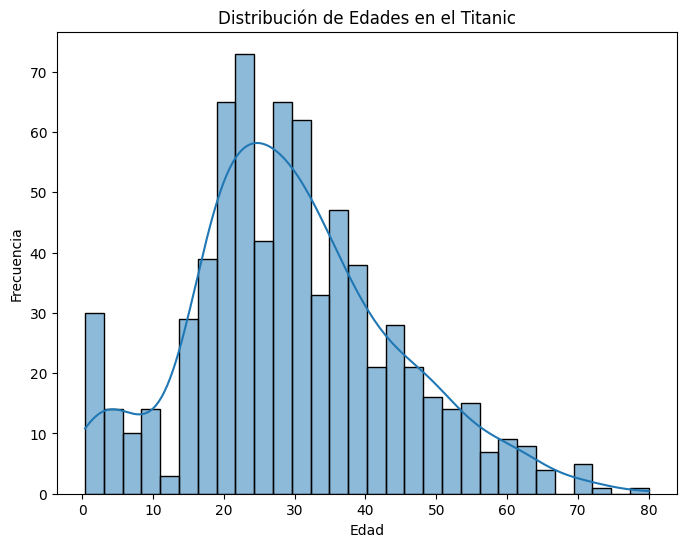

In [63]:
# Histogramas de Edades:
plt.figure(figsize=(8, 6))
sns.histplot(df['Age'].dropna(), bins=30, kde=True)
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.title('Distribución de Edades en el Titanic')
plt.show()



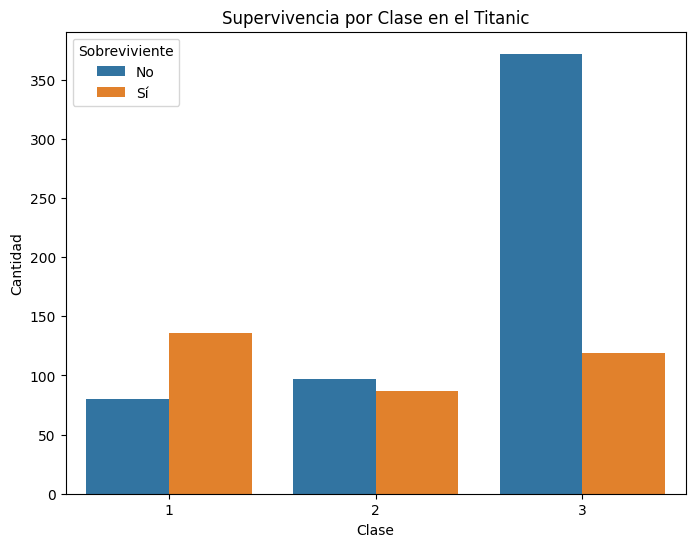

In [64]:
# Gráfico de Barras de Supervivencia por Clase:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.title('Supervivencia por Clase en el Titanic')
plt.legend(title='Sobreviviente', labels=['No', 'Sí'])
plt.show()

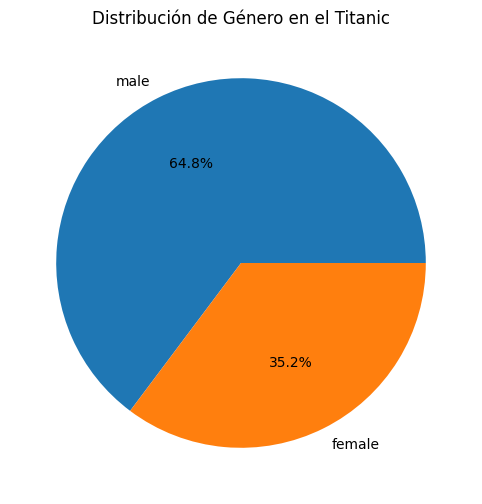

In [65]:
# Gráfico de Torta de Género:
plt.figure(figsize=(8, 6))
df['Sex'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribución de Género en el Titanic')
plt.ylabel('')
plt.show()

### 🧠 Interpretación de Gráfico

Los gráficos revelan que la población a bordo del Titanic era mayoritariamente masculina (64.8%) y que la supervivencia estuvo directamente condicionada por la clase social del boleto. La primera clase fue la única donde el número de sobrevivientes superó al de fallecidos, mientras que la tercera clase sufrió el mayor impacto de la tragedia con una pérdida masiva que superó los 350 pasajeros, evidenciando una marcada desigualdad en el rescate.

## 🚀 1.8. Limpieza y Exploración Inicial:

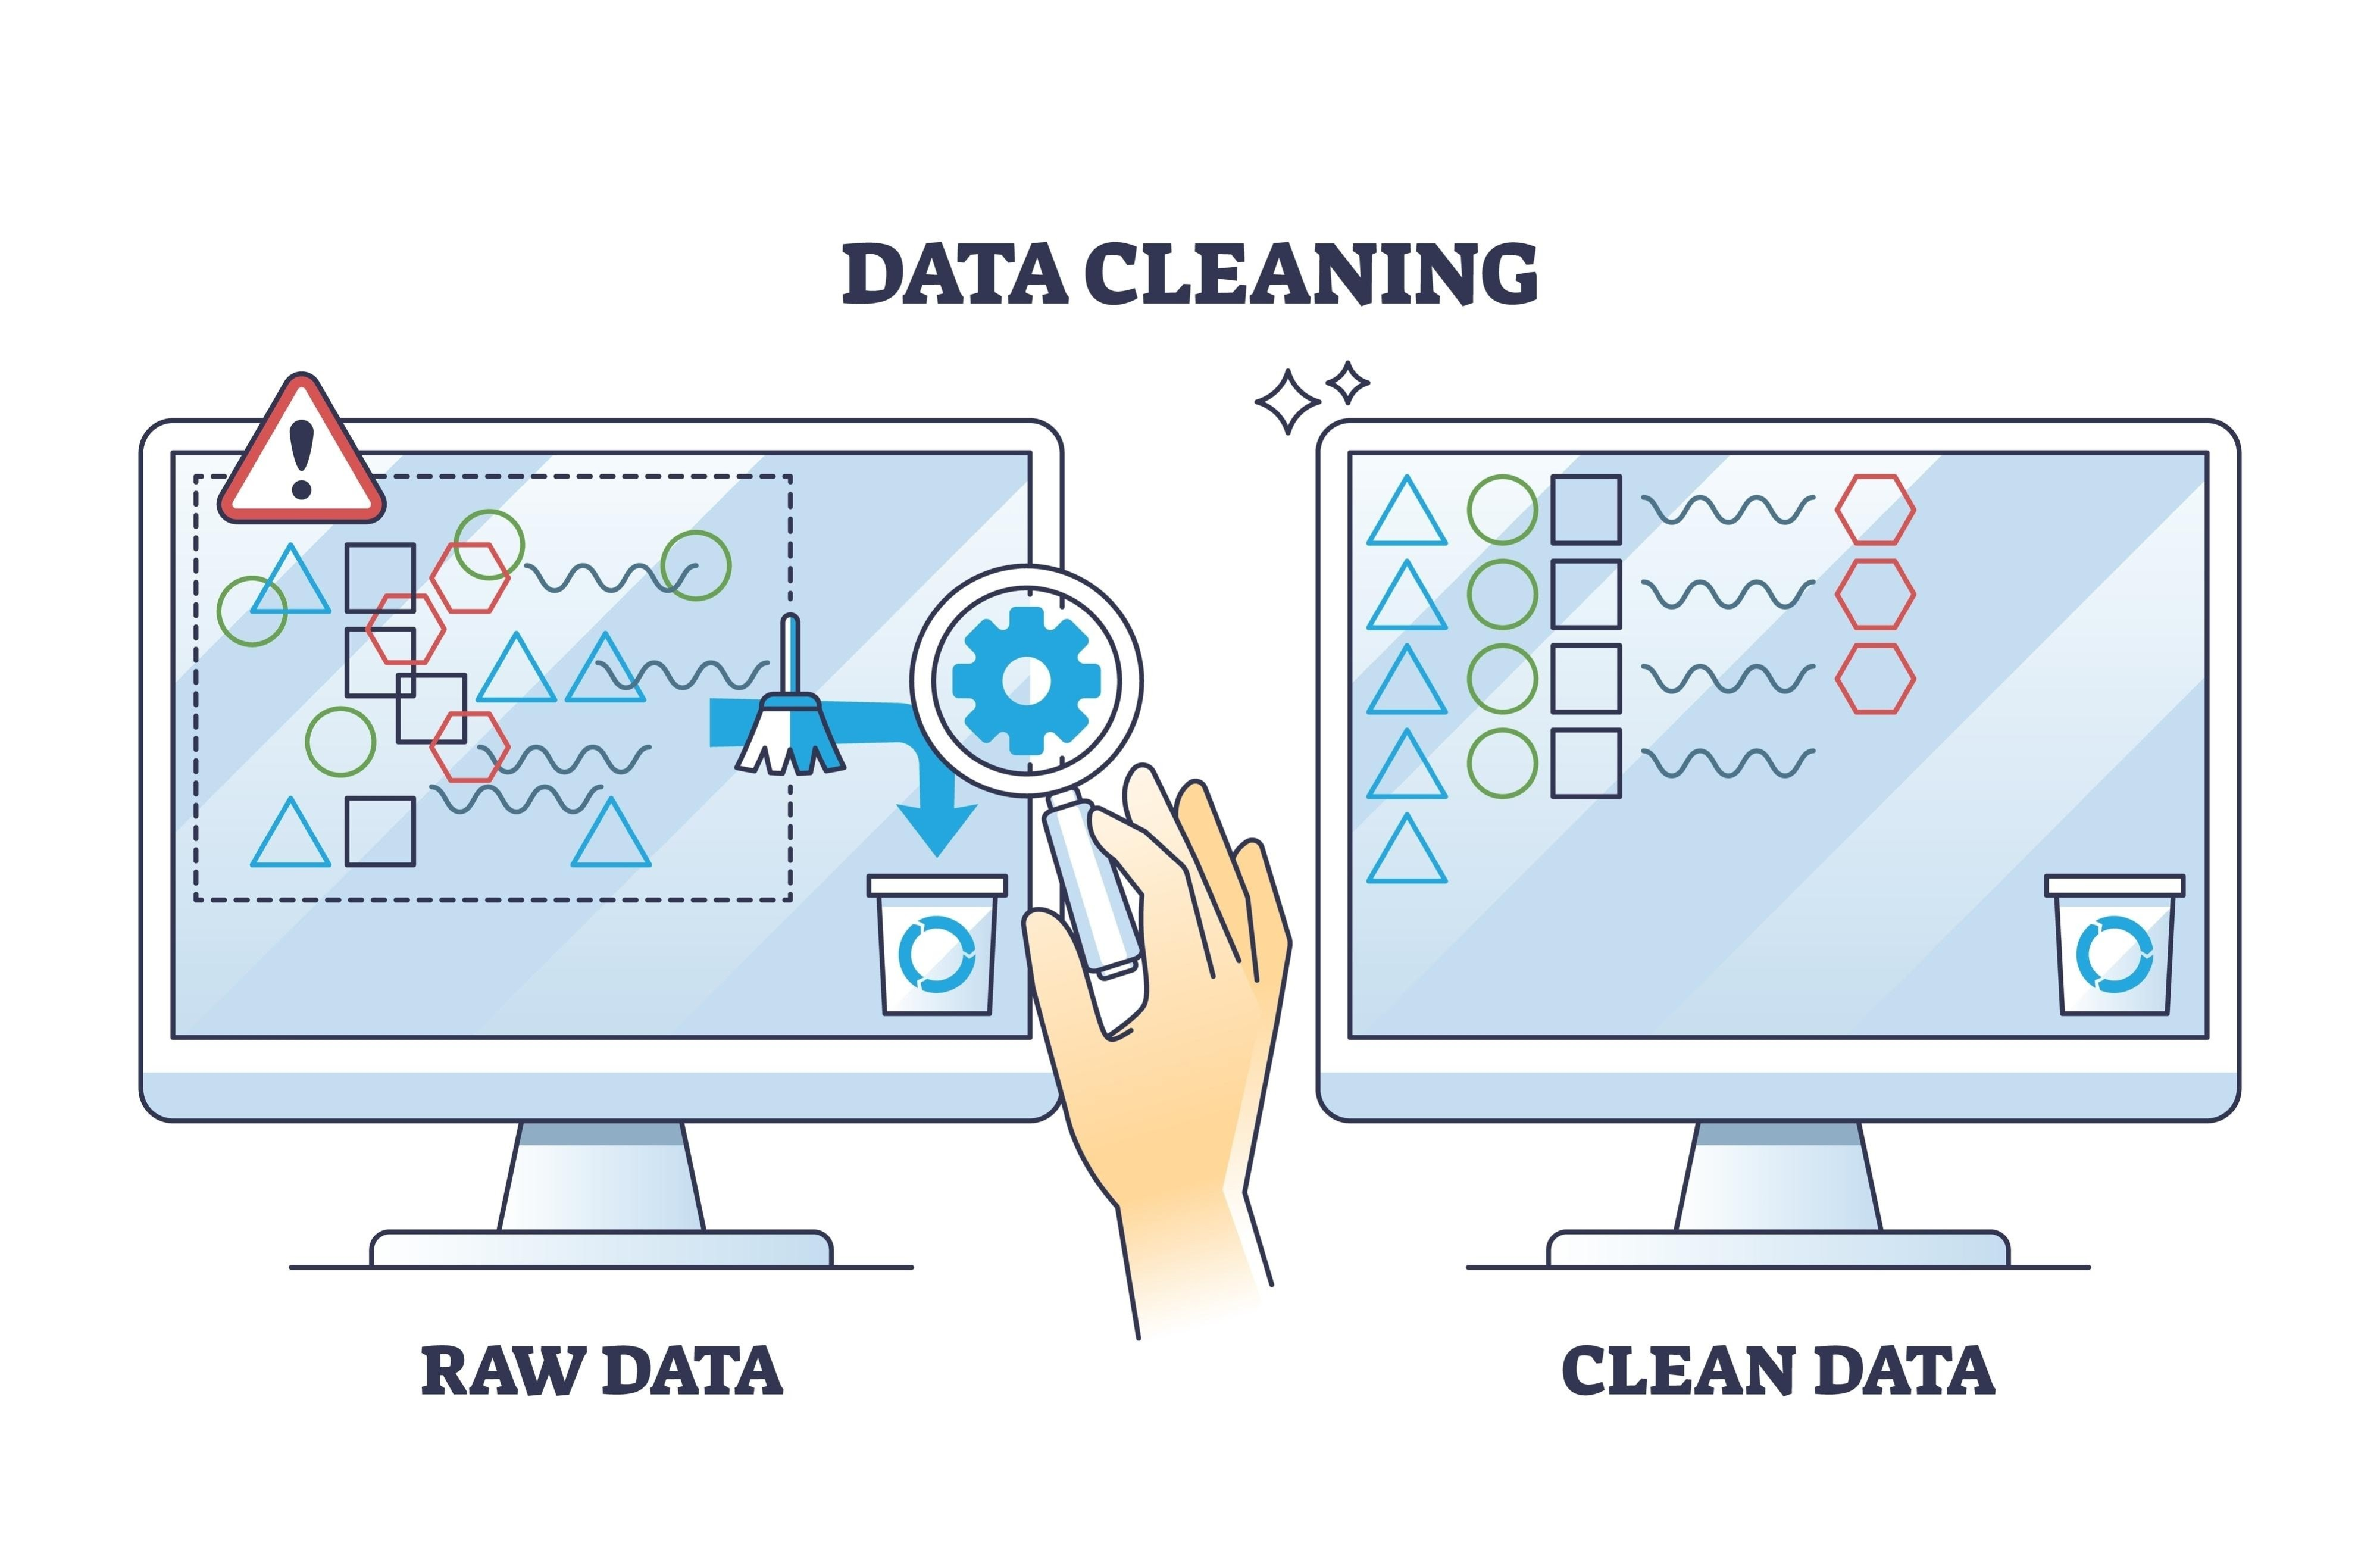

## 🚀 1.9. Tratamiento de Valores Nulos
Para garantizar que el análisis sea estadísticamente significativo y técnicamente eficiente, se han aplicado las siguientes reglas de procesamiento sobre el dataset:

Identificar las columnas que presentan más del 30 % de valores nulos para decidir su eliminación.
Adicional, se reviso las columnas por la varianza para eliminar aquellas que no sean necesarias.
En el caso de columnas críticas con pocos valores faltantes, se realiza la imputación de datos.

El código **analiza los valores nulos**, elimina las columnas con **más del 30 % de datos faltantes** y muestra un **comparativo del número de columnas antes y después** del proceso de limpieza.


In [66]:
# Obtiene el número total de columnas del DataFrame original
total_columnas_antes = df.shape[1]
total_columnas_antes  # Muestra el total de columnas antes del tratamiento

# Calcula el porcentaje de valores nulos por cada columna
nulos = (
    df.isna()          # Identifica valores nulos (NaN)
      .mean()          # Calcula la proporción de nulos por columna
      .mul(100)        # Convierte la proporción a porcentaje
      .round(2)        # Redondea a 2 decimales
      .reset_index()   # Convierte el índice en una columna
)

# Renombra las columnas del DataFrame resultante
nulos.columns = ['Columna', 'Porcentaje_nulos']

# Selecciona las columnas que tienen más del 30% de valores nulos
columnas_mayor_30 = (
    nulos[nulos['Porcentaje_nulos'] > 30]['Columna']
    .tolist()          # Convierte los nombres de columnas a una lista
)

# Elimina del DataFrame las columnas con más del 30% de nulos
df_reducido = df.drop(columns=columnas_mayor_30)

# "Las columnas que tienen un valor único... probablemente sean inútiles"
for col in df_reducido.columns:
    if df_reducido[col].nunique() == 1:
        print(f"Eliminando columna de varianza cero: {col}")
        df_reducido = df_reducido.drop(columns=[col])

print(f"Dimensiones post-limpieza básica: {df_reducido.shape}")

# Obtiene el total de columnas después de eliminar las columnas con muchos nulos
total_columnas_despues = df_reducido.shape[1]
total_columnas_despues  # Muestra el total de columnas después del tratamiento

# Crea un DataFrame resumen con el antes y después del tratamiento de columnas
resumen_columnas = pd.DataFrame({
    'Estado': ['Antes del tratamiento', 'Después del tratamiento'],
    'Total_columnas': [total_columnas_antes, total_columnas_despues]
})

# Muestra el resumen final
resumen_columnas


Dimensiones post-limpieza básica: (891, 11)


,Estado,Total_columnas
0,Antes del tratamiento,12
1,Después del tratamiento,11


Luego de validar, nos percatamos que no existen columnas para eliminar.

### Filtrado por Umbral de Nulos (30%)
Se decidió eliminar automáticamente cualquier columna que presentara más del 30% de valores ausentes.
###¿Por qué?:
Una columna con un alto índice de nulos introduce sesgos y reduce la confiabilidad de cualquier modelo o gráfico. Al superar el 30%, la cantidad de datos "inventados" o imputados necesarios para rellenar.

## 🚀 1.10. Normalizacion de datos

Como parte de este proyecto necesitamos normalizar los datos para mejorar la convergencia, estabilidad y rendimiento de un modelo. Sin embargo, para el analisis que estamos realizando nos ayudará a mejorar la interpretacion de los datos médicos.

In [67]:
# Según las recomendaciones investigadas y teniendo en cuenta que son datos médicos vamos a usar StandardScaler para modelos entrenados con regresión lineal

from sklearn.preprocessing import StandardScaler

# Eliminar columnas poco útiles
df = df.drop(
    columns=[
        "PassengerId",
        "Name",
        "Ticket",
        "Cabin"
    ]
)

# Completar nulos
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Convertir Sex
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

# One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=["Embarked"],
    drop_first=True
)

X = df.drop(columns=["Survived"])
Y = df["Survived"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Creamos un nuevo Dataset

df_train = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

# Revisamos el nuevo dataset
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      891 non-null    float64
 1   Sex         891 non-null    float64
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    float64
 4   Parch       891 non-null    float64
 5   Fare        891 non-null    float64
 6   Embarked_Q  891 non-null    float64
 7   Embarked_S  891 non-null    float64
dtypes: float64(8)
memory usage: 55.8 KB



### 🧠 Interpretación

La normalización era necesaria porque las variables que tiene el dataset son de escalas heterogenéneas, es decir que tienen escalas más dispersas porque son datos clinicos y de cara a un modelo que se desea entrenar podria tener problemas debido a esas escalar que serán relevantes para el modelo pero no tiene que ser asi. Al ser sencibles a la magnitud es mejor normalizarlos a valores que puedan ser interpretados correctamente para una correcta predicción.

#2️⃣ Fase 2: Analisis Exploratorio (EDA) de Cáncer de Mama

En esta sección, vamos a realizar la interpretación de los datos proporcionados.

### 🚀 2.1. Matriz de correlacion

Generaremos una matriz de correlaccion con todas las columnas existentes en el dataset.

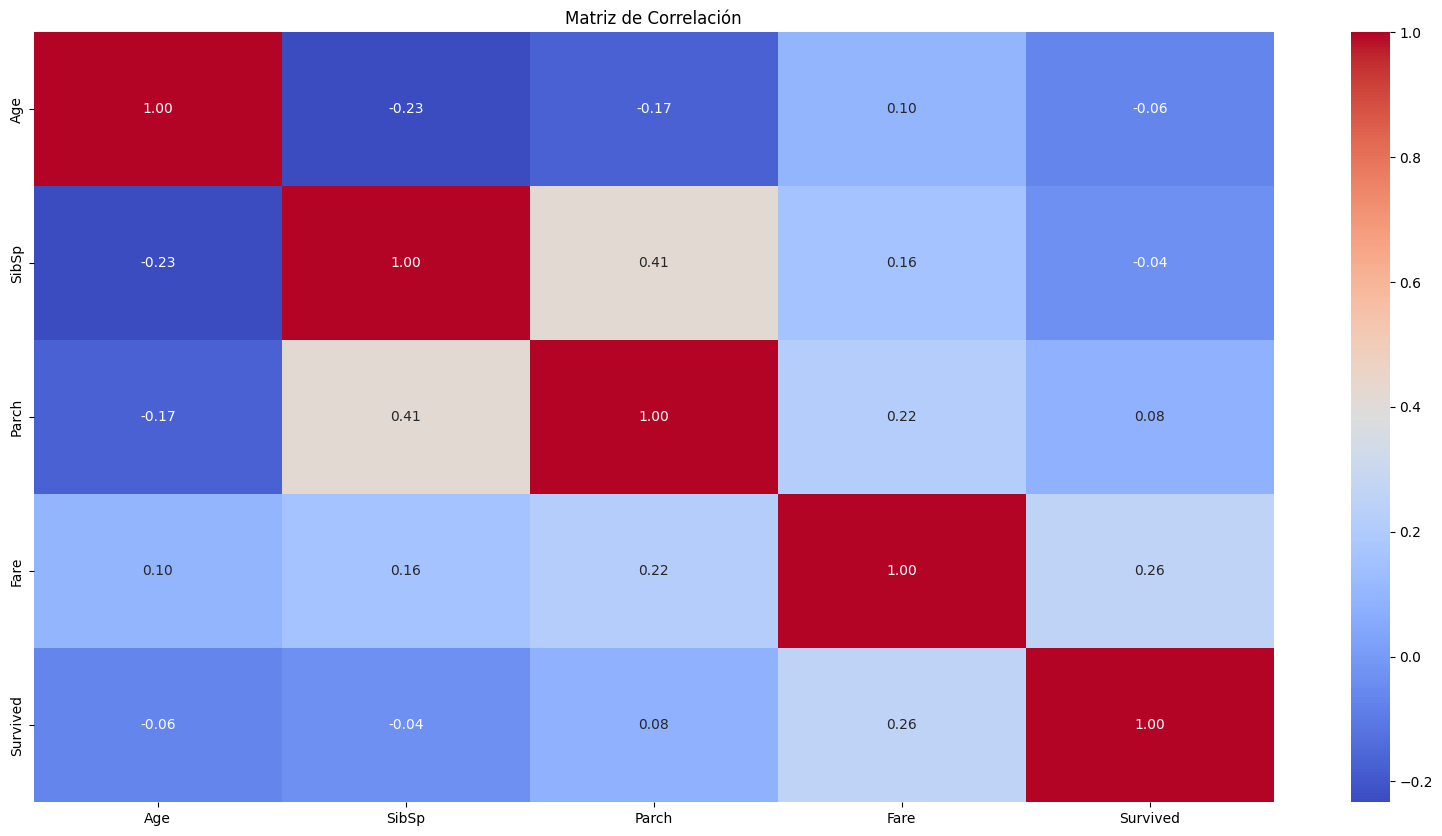

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Análisis de Correlación
# Se podría eliminar aquellas variables que tengan una correlación baja o nula
# con la variable objetivo, ya que podrían no aportar información relevante al modelo.
# Además, se podría quitar ciertas variables que están altamente correlacionadas entre sí.

# Seleccionar las variables numéricas principales para el análisis de correlación y el target
variables_numericas = ['Age', 'SibSp', 'Parch', 'Fare', 'Survived']

# Crearemos una matriz de correlaccion entre los valores
corr_matrix = df[variables_numericas].corr()


plt.figure(figsize=(20,10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Matriz de Correlación")
plt.show()


### 🧠 Interpretación de Gráfico

La matriz de correlación del dataset Titanic muestra que no existen relaciones lineales fuertes entre las variables numéricas analizadas y la variable objetivo Survived. La correlación más alta con la supervivencia corresponde a Fare (0.26), lo que sugiere que los pasajeros que pagaron tarifas más elevadas tuvieron una mayor probabilidad de sobrevivir, posiblemente por viajar en clases superiores. Asimismo, se observa una correlación moderada entre SibSp y Parch (0.41), indicando que los pasajeros que viajaban con hermanos o cónyuges también tendían a viajar con padres o hijos. Por otro lado, la edad presenta una correlación muy débil con la supervivencia (-0.06), lo que indica que, por sí sola, no es un factor determinante. En general, el análisis sugiere que las variables numéricas tienen una capacidad explicativa limitada de forma individual, por lo que será necesario considerar variables categóricas como Sex, Pclass y Embarked, así como modelos de Machine Learning capaces de capturar relaciones más complejas entre las características de los pasajeros y su supervivencia.

### 🚀 2.2. Submatriz de correlacion

En esta submatriz tendremos filtrados las columnas con mayor correlacion para entender mejor este dataset.

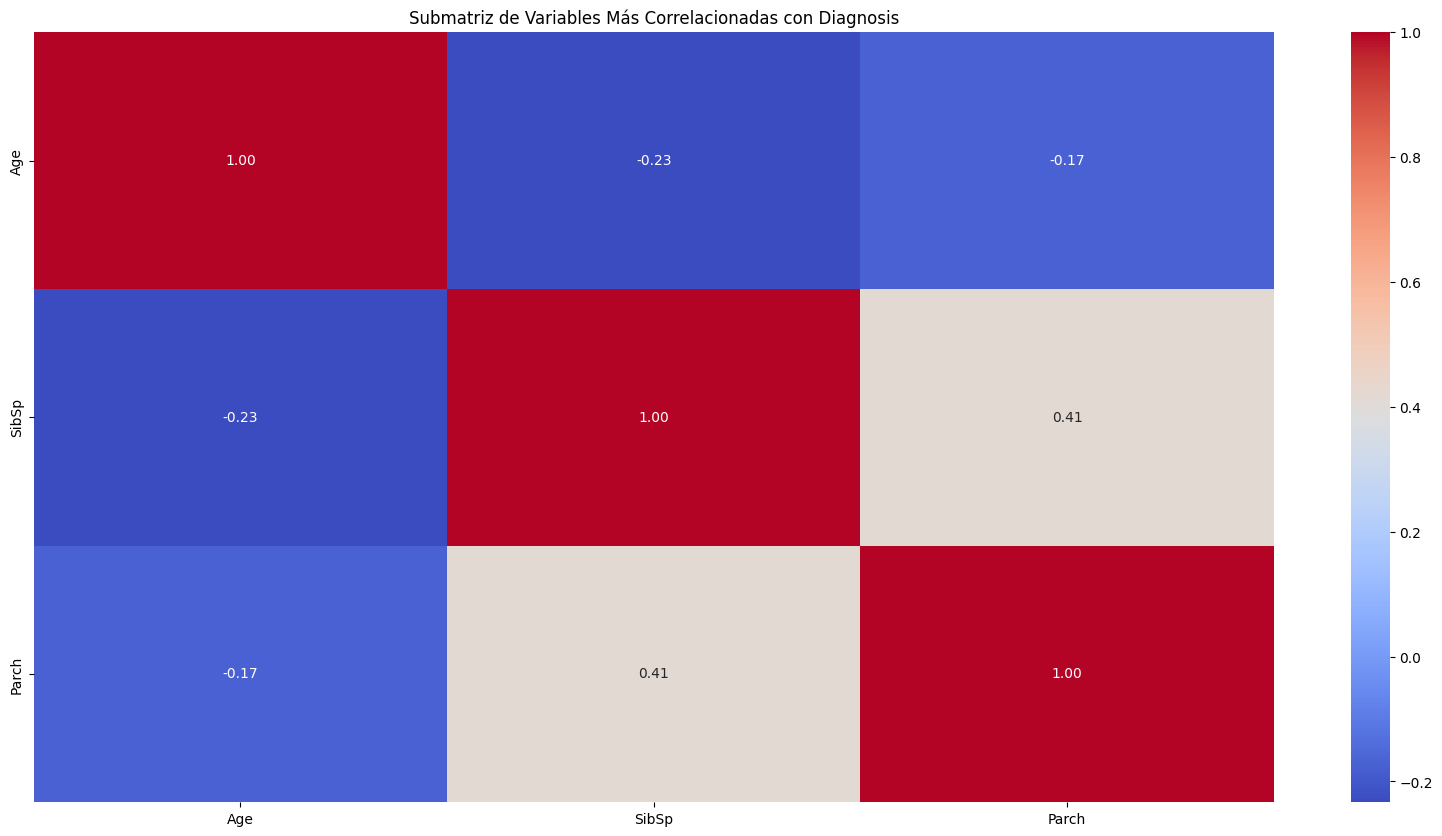

In [69]:
# Obtener correlación con Diagnosis
top_corr = (
    corr_matrix["Age"]
    .abs()
    .sort_values(ascending=False)
)

# Elegir top 10 variables
top_variables = top_corr.head(3).index

# Crear submatriz
submatriz = corr_matrix.loc[top_variables, top_variables]

# Graficar
plt.figure(figsize=(20,10))

sns.heatmap(
    submatriz,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Submatriz de Variables Más Correlacionadas con Diagnosis")
plt.show()

### 🧠 Interpretación de Gráfico

Esta submatriz muestra que las variables SibSp (número de hermanos/cónyuges a bordo) y Parch (número de padres/hijos a bordo) presentan una correlación positiva moderada (0.41), lo que indica que los pasajeros que viajaban con familiares cercanos tendían a hacerlo en grupos familiares. Por otro lado, la variable Age presenta correlaciones negativas débiles con SibSp (-0.23) y Parch (-0.17), sugiriendo que los pasajeros más jóvenes solían viajar acompañados de familiares con mayor frecuencia que los pasajeros de mayor edad. En general, no se observan correlaciones fuertes entre estas variables, por lo que cada una aporta información diferente al modelo y no existe un problema significativo de multicolinealidad. Esto resulta favorable para los algoritmos de clasificación, ya que pueden aprovechar información complementaria de cada característica para predecir la supervivencia de los pasajeros.

### 🚀 2.3. Distribución de clases

En este gráfico verificaremos si hay desbalance en los casos por el diagnostico.

/tmp/ipykernel_802/2105660743.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Died", "Alive"])


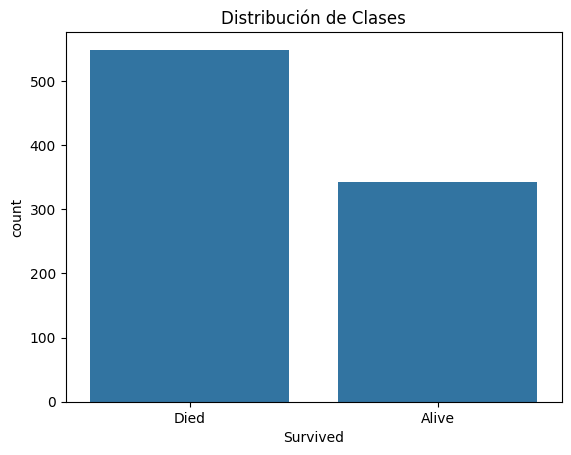

In [70]:
# Veremos un gráfico de los casos (Conteo automático)
ax = sns.countplot(
    data=df,
    x="Survived"
)

# Cambiar etiquetas del eje X
ax.set_xticklabels(["Died", "Alive"])

plt.title("Distribución de Clases")
plt.show()

### 🧠 Interpretación de Gráfico

Este gráfico muestra la distribución de la variable objetivo Survived en el dataset del Titanic. Se observa que la cantidad de pasajeros que no sobrevivieron (Died) es considerablemente mayor que la de aquellos que sobrevivieron (Alive), con aproximadamente 549 fallecidos y 342 sobrevivientes. Esto indica la presencia de un desbalance moderado entre las clases, lo que debe considerarse durante el entrenamiento de modelos de Machine Learning, ya que métricas como la exactitud (Accuracy) podrían resultar engañosas. Por esta razón, es recomendable complementar la evaluación con métricas como Precisión, Sensibilidad (Recall), F1-Score y AUC, que ofrecen una visión más completa del desempeño del modelo al predecir la supervivencia de los pasajeros.

### 🚀 2.4. Boxplots por diagnóstico

En este gráfico observaremos si los tumores malignos tienen mayor tamaño, más irregularidad o mayor concavidad que clínicamente es muy útila.

/tmp/ipykernel_802/362728137.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Died", "Alive"])


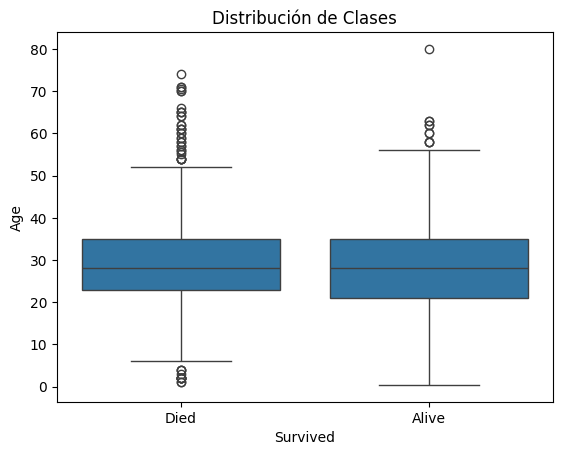

In [71]:
# Gráficaremos el boxplot por la columna Diagnosis

ax = sns.boxplot(
    x="Survived",
    y="Age",
    data=df
)

# Cambiar etiquetas del eje X
ax.set_xticklabels(["Died", "Alive"])

plt.title("Distribución de Clases")
plt.show()

### 🧠 Interpretación de Gráfico

El gráfico de la imagen image_b6bb63.png muestra un diagrama de caja (boxplot) que compara la distribución de la edad (Age) entre dos grupos de la variable de supervivencia (Survived): los que fallecieron (Died) y los que sobrevivieron (Alive). A primera vista, se observa que la mediana de edad es prácticamente idéntica en ambos grupos (alrededor de los 28 años), y la dispersión central (el tamaño de las cajas azules que representan el rango intercuartílico) es muy similar, lo que sugiere que, a nivel general, la edad no parece haber sido un factor determinante por sí solo en la supervivencia. Sin embargo, el grupo "Alive" muestra una extensión ligeramente mayor hacia edades más tempranas (cercanas a cero), reflejando la prioridad que se le suele dar a los niños, mientras que ambos grupos presentan múltiples valores atípicos (outliers) en las edades avanzadas, destacando un caso extremo de un sobreviviente de 80 años.

### 🚀 2.5. Detección de Outliers

En este gráfico observaremos los posibles outliers o valores atípicos que podremos encontrar en el dataset

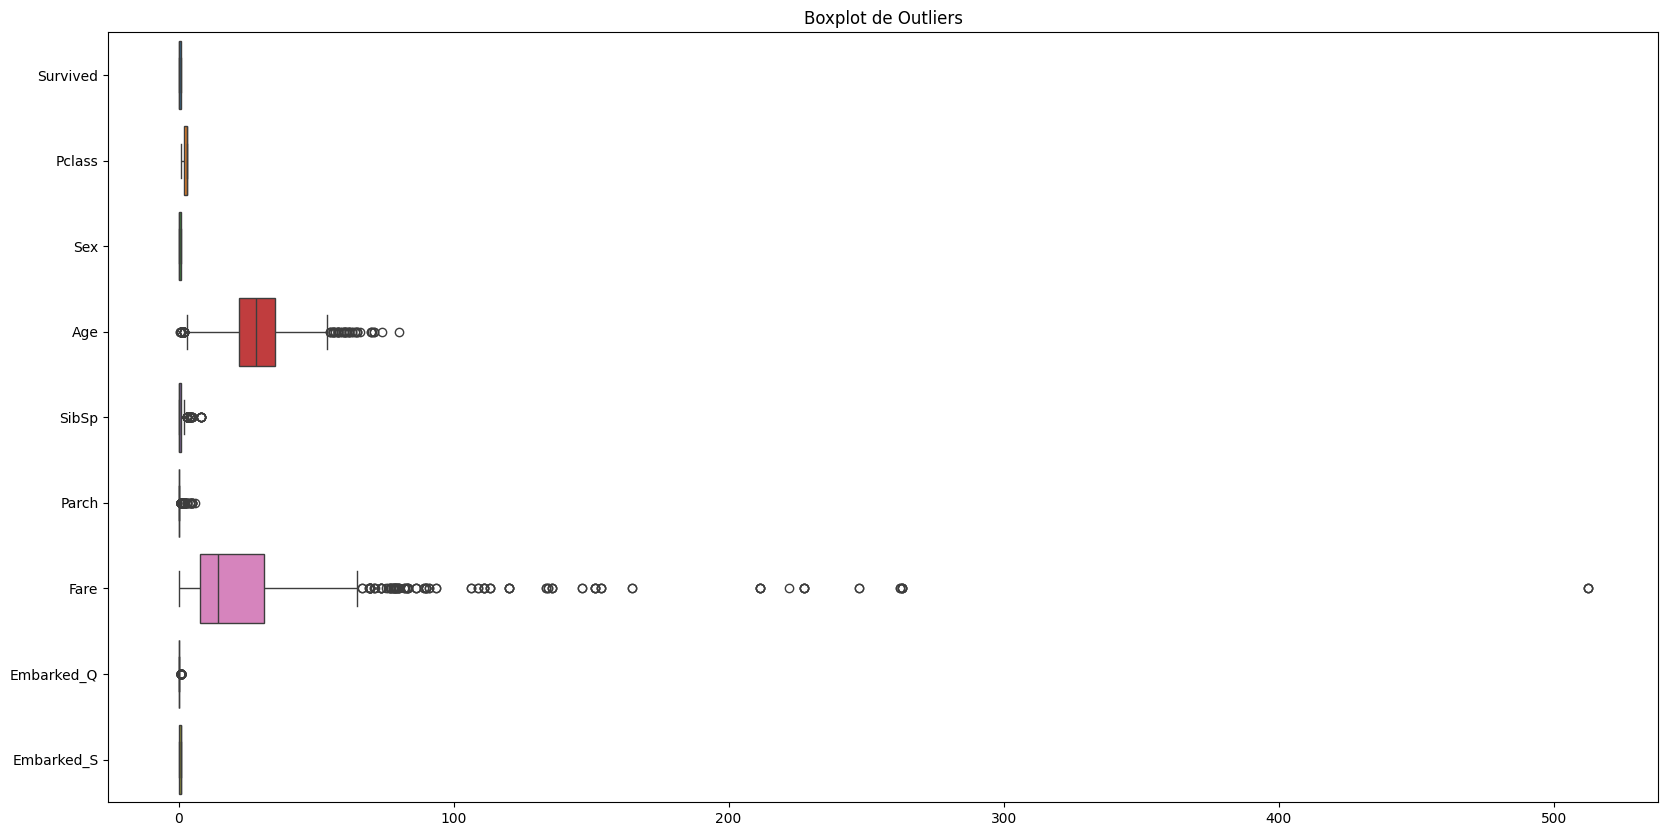

In [72]:
# Gráfico de outliers
plt.figure(figsize=(20, 10))

sns.boxplot(
    data=df,
    orient="h"
)

plt.title("Boxplot de Outliers")
plt.show()

### 🧠 Interpretación de Gráfico

Este gráfico de cajas (Boxplot de Outliers) permite identificar que Fare (Tarifa) y Age (Edad) son las variables continuas con mayor presencia de valores atípicos en el conjunto de datos. En el caso de la tarifa, la caja rosa comprimida refleja que la gran mayoría pagó boletos económicos, pero existe una larga estela de outliers que se extiende hacia la derecha, destacando un valor extremo que supera los 500. Por su parte, la edad muestra una concentración central entre los 20 y 40 años, con valores atípicos que representan tanto a niños muy pequeños como a adultos mayores de hasta 80 años. Finalmente, variables como SibSp y Parch muestran pocos valores atípicos correspondientes a familias numerosas, mientras que las variables categóricas o binarias (como Sex, Survived o las de embarque) aparecen distorsionadas y comprimidas cerca del cero debido a que este tipo de gráfico no está diseñado para medir datos no continuos.

### 🚀 2.6. Pairplot de relaciones entre diagnosticos

En este gráfico observaremos las relaciones entre varibles y separación visual de clases.

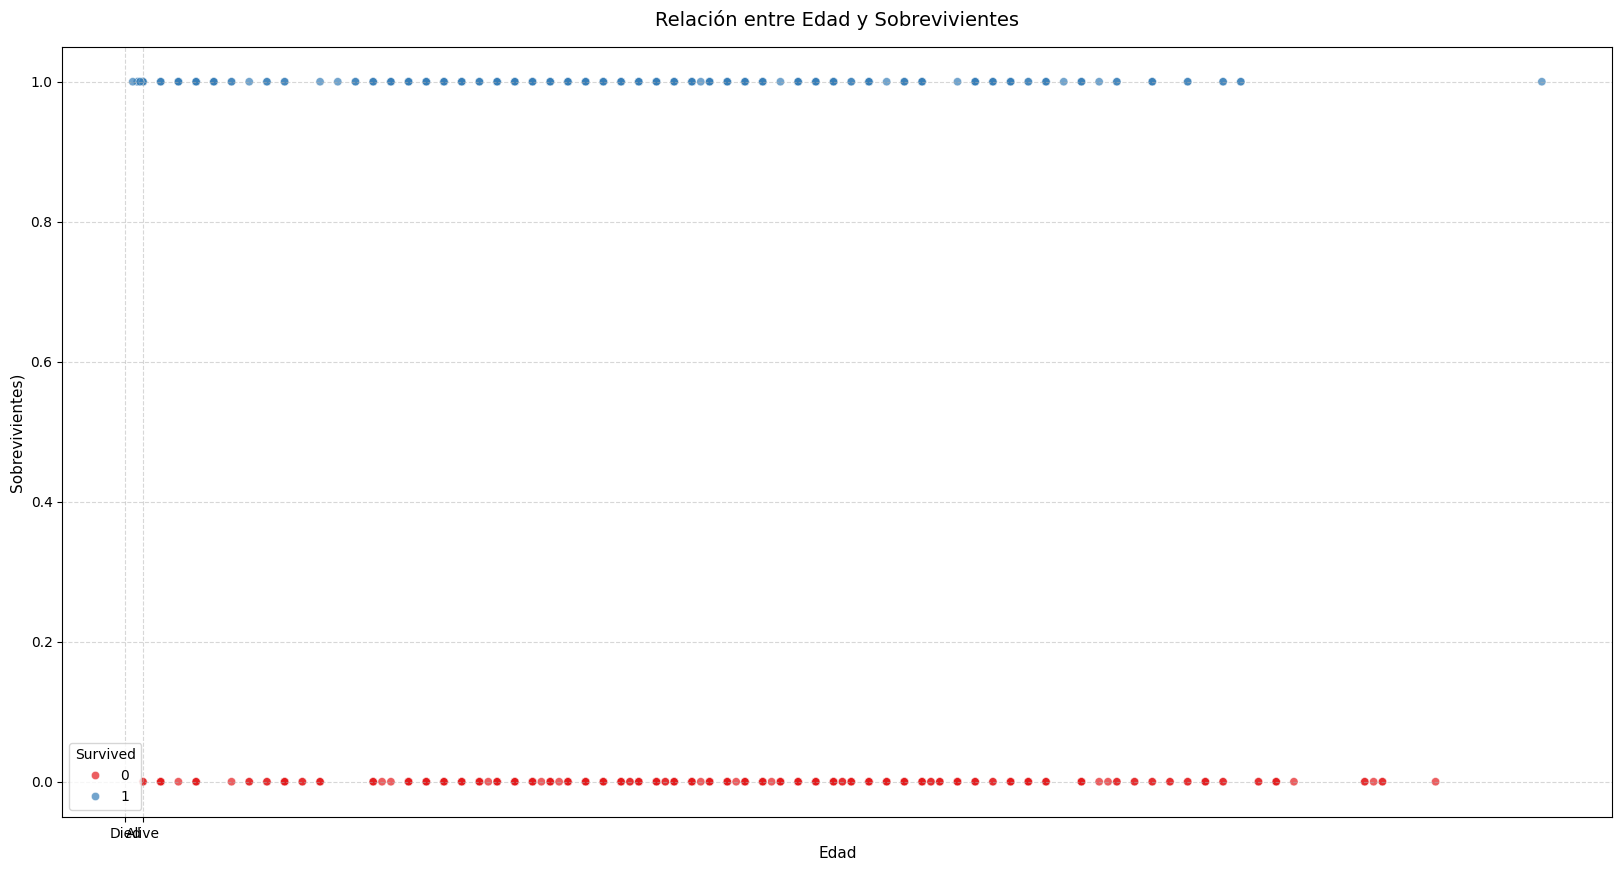

In [73]:
# Gráfico de pairplot

plt.figure(figsize=(20, 10))

ax = sns.scatterplot(
    data=df,
    x="Age",
    y="Survived",
    hue="Survived",
    palette="Set1", # Colores claros para contrastar benigno/maligno
    alpha=0.7
)
ax.set_xticks([0, 1])
# Luego le asignamos los nombres de texto correspondientes
ax.set_xticklabels(["Died", "Alive"])

plt.title("Relación entre Edad y Sobrevivientes", fontsize=14, pad=15)
plt.xlabel("Edad", fontsize=11)
plt.ylabel("Sobrevivientes)", fontsize=11)

plt.grid(True, linestyle="--", alpha=0.5) # Malla opcional para mejor lectura
plt.show()

### 🧠 Interpretación de Gráfico

Este gráfico de dispersión (scatterplot) intenta mostrar la relación entre la edad y la supervivencia, dividiendo los datos en dos franjas horizontales: los pasajeros que fallecieron (puntos rojos en el valor 0.0) y los que sobrevivieron (puntos azules en el valor 1.0). Debido a que la supervivencia es una variable binaria y discontinua, los puntos simplemente se alinean en dos franjas a lo largo de todo el espectro de edades, lo que dificulta extraer una conclusión clara sobre la densidad o tendencia de supervivencia a simple vista. Aun así, se puede apreciar visualmente que hubo sobrevivientes (puntos azules) y fallecidos (puntos rojos) en prácticamente todas las edades, incluyendo una notable concentración de sobrevivientes en edades muy tempranas (niños pequeños a la izquierda) y un único sobreviviente de edad avanzada en el extremo derecho que alcanza los 80 años.

# 3️⃣ Fase 3: Conclusiones del proceso y análisis de datos para cancer de mama

Agregue sus conclusiones, desarrollando un análisis integral de todo el proceso
realizado. En su reflexión, identifique y explique:

## 🚀 3.1. ¿Qué podemos concluir en base al analisis realizado?


## ⭐ Respuesta

Al integrar el análisis de los tres gráficos, la conclusión principal es que la edad, por sí sola, no fue el factor determinante ni lineal para la supervivencia de los pasajeros, ya que tanto las medianas de edad como la distribución general de los fallecidos y sobrevivientes son casi idénticas. Sin embargo, los datos revelan matices importantes en los extremos demográficos: existió una clara prioridad de salvamento para los niños pequeños (lo que comprime la dispersión hacia el cero en el grupo de supervivientes) y, de igual manera, se destaca el caso excepcional de un adulto mayor de 80 años que logró salvarse. Por otro lado, el análisis de la estructura de los datos refleja que la variable socioeconómica —representada por el costo de la tarifa (Fare)— presenta una desigualdad extrema con valores atípicos que superan los 500, sugiriendo que el impacto del nivel económico o la clase del boleto podría ser un predictor de supervivencia mucho más contundente y diferenciador que la edad.

# 4️⃣ Fase 4: Aplicación en Entorno Laboral

## 🚀 Redacta una sección final de aplicación:
- Cada miembro del equipo colocara su nombre una explicación de como aplicaría
lo aprendido en esta semana en su entorno profesional.

# 🖥️ **ROMEL MICHAEL CERNA PACHECO**
La aplicación del preprocesamiento y del análisis exploratorio de datos (EDA), combinada con el análisis del negocio, proporciona información valiosa para definir futuros planes de acción. Esto permite comprender las métricas clave y las variables más relevantes que contribuyen a alcanzar los objetivos planteados. Tanto en casos prácticos como en entornos laborales, estos análisis sirven como base para impulsar la mejora continua mediante indicadores de gestión (KPIs) que orienten la toma de decisiones y ayuden a identificar el origen de los problemas.

# 🖥️ **CARRERA DIAZ CHRISTIAN JAVIER**
El análisis de datos y las técnicas de Machine Learning permiten identificar patrones relevantes para mejorar la toma de decisiones en entornos reales. En un entorno laboral, estos procesos pueden aplicarse para detectar anomalías, optimizar reportes, automatizar análisis y generar información más precisa para apoyar decisiones estratégicas basadas en datos.

# 🖥️ **KEVIN YITZHACK AMBULUDI PATIÑO**

Los primeros pasos para analizar los datos de manera oportuna se centran principalmente en el preprocesamiento de la información, ya que este permite garantizar una base de datos confiable, limpia y estructurada. Posteriormente, el análisis exploratorio de datos (EDA) desempeña un papel fundamental al ayudar a identificar patrones, relaciones y posibles causalidades entre las variables, las cuales pueden resultar significativas para la comprensión del problema. Este proceso facilita la detección de características esenciales y comportamientos relevantes que brindan los primeros indicios para encontrar una solución adecuada.

En el caso del análisis de datos relacionado con el diagnóstico de cáncer de mama, se puede evidenciar que la caracterización de variables permite identificar aquellos factores más importantes para la clasificación y predicción de casos. De manera similar, en el ámbito laboral, este tipo de análisis puede aplicarse para detectar clientes con riesgo de caer en mora, evaluando variables como el comportamiento financiero, condiciones laborales y características sociodemográficas. Con esta información, es posible estimar la probabilidad de incumplimiento de pago y, a partir de ello, implementar estrategias de mitigación, como campañas preventivas, limitación de montos de crédito o, en casos de alto riesgo, la restricción en la aprobación de créditos.